In [139]:
%matplotlib inline


In [140]:
#imported essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from imblearn.over_sampling import RandomOverSampler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, accuracy_score, roc_auc_score
import optuna 

In [141]:
#loaded the dataset with removing irrelevant features
df1 = pd.read_csv('shipment-sensor-dataset.csv').drop(['silent_failure', 'shipment_id', 'temp_max_c', 'temp_min_c', 'temp_std_c', 'rh_std', 'rh_max', 'temp_recovery_rate'], axis = 1)

In [142]:
df1.rename(columns={'feature_x3': 'shipment_failure'}, inplace=True)

In [143]:
df1

,transit_days,door_opens,temp_mean_c,rh_mean,package_type,product_volume_l,fill_ratio,carrier_id,origin_zone,dest_zone,leg_count,sensor_gap_hours,vibration_index,feature_x1,feature_x2,shipment_failure
0,4.515,21,9.599,0.5914,2,16.19,0.8300,10,0,0,1,1.005,2.2727,-2.2325,-0.5249,0
1,1.696,5,2.411,0.4216,2,7.31,0.7562,6,2,0,1,0.541,2.1837,2.6035,-0.6972,0
2,1.319,2,3.261,0.4410,0,10.21,0.7271,0,5,0,2,0.395,2.5449,0.4678,0.7930,0
3,6.495,19,5.188,0.4522,1,0.87,0.8380,7,1,5,1,1.371,1.3480,0.5615,0.4204,0
4,1.795,4,3.520,0.4590,0,11.50,0.6914,4,0,5,2,0.089,0.5495,-1.5750,0.8817,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,3.006,9,2.974,0.4437,1,12.23,0.5384,11,2,2,1,1.500,1.3306,0.4904,-0.6849,0
7996,2.759,3,2.672,0.3809,1,20.51,0.6110,9,4,3,2,0.451,1.8505,0.0707,0.4956,1
7997,8.130,7,4.471,0.5619,0,14.50,0.5432,7,1,5,2,1.114,0.6816,-1.6124,-1.6908,1
7998,1.520,2,4.033,0.4413,0,9.20,0.9640,6,4,4,1,0.892,1.2974,1.4130,-0.5097,0


In [144]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transit_days      8000 non-null   float64
 1   door_opens        8000 non-null   int64  
 2   temp_mean_c       8000 non-null   float64
 3   rh_mean           8000 non-null   float64
 4   package_type      8000 non-null   int64  
 5   product_volume_l  8000 non-null   float64
 6   fill_ratio        8000 non-null   float64
 7   carrier_id        8000 non-null   int64  
 8   origin_zone       8000 non-null   int64  
 9   dest_zone         8000 non-null   int64  
 10  leg_count         8000 non-null   int64  
 11  sensor_gap_hours  8000 non-null   float64
 12  vibration_index   8000 non-null   float64
 13  feature_x1        8000 non-null   float64
 14  feature_x2        8000 non-null   float64
 15  shipment_failure  8000 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 1000

In [145]:
df1.duplicated().sum()

0

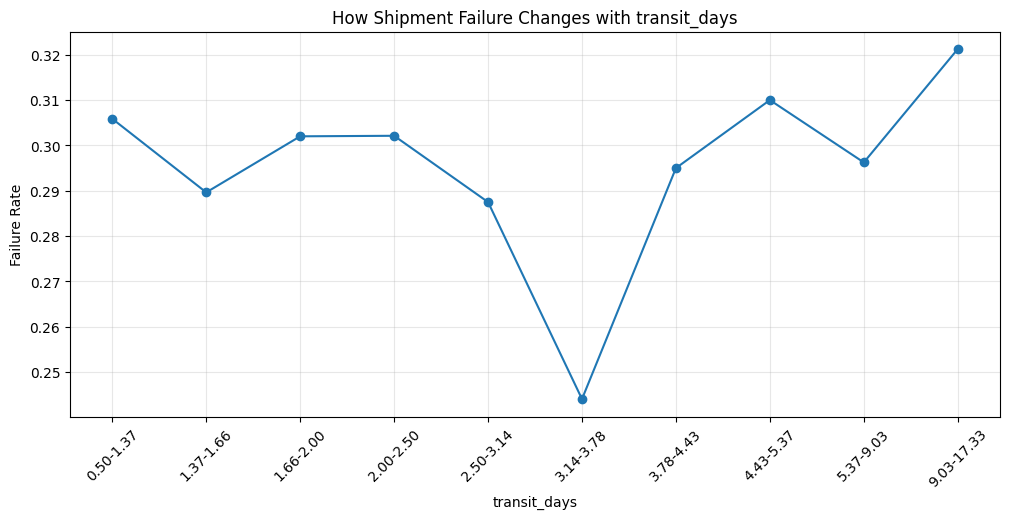

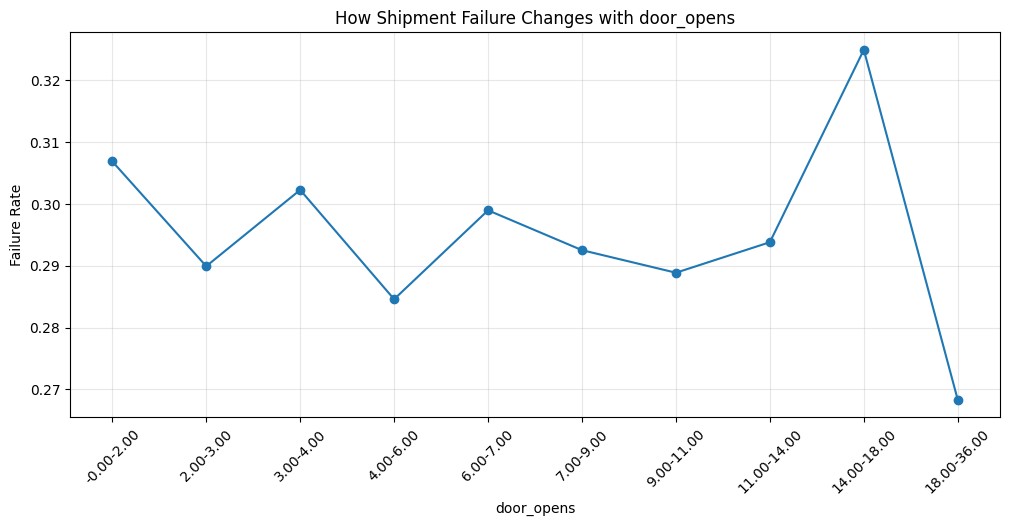

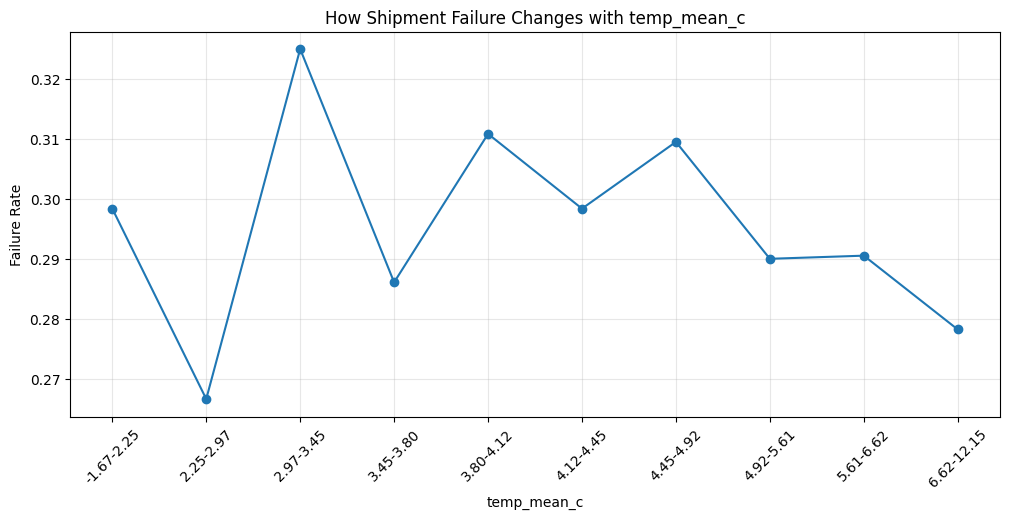

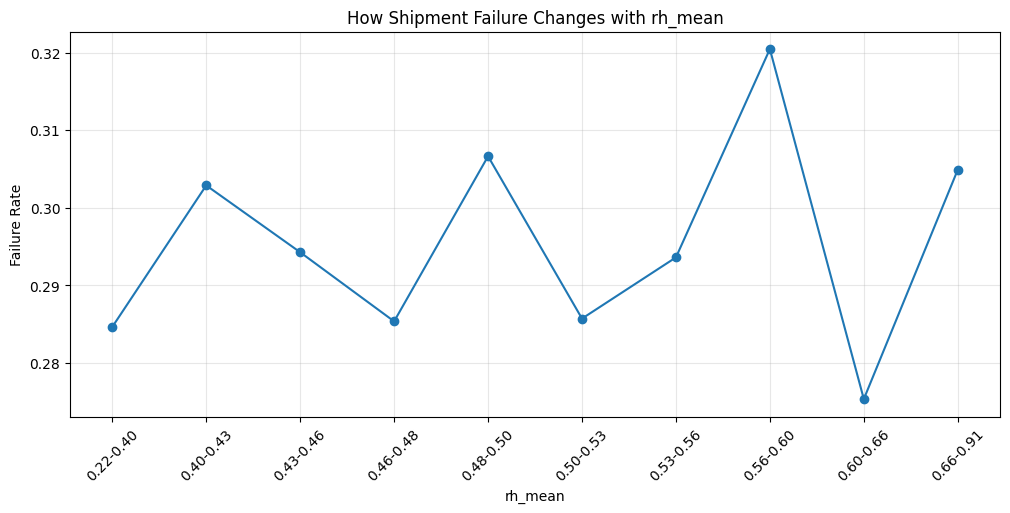

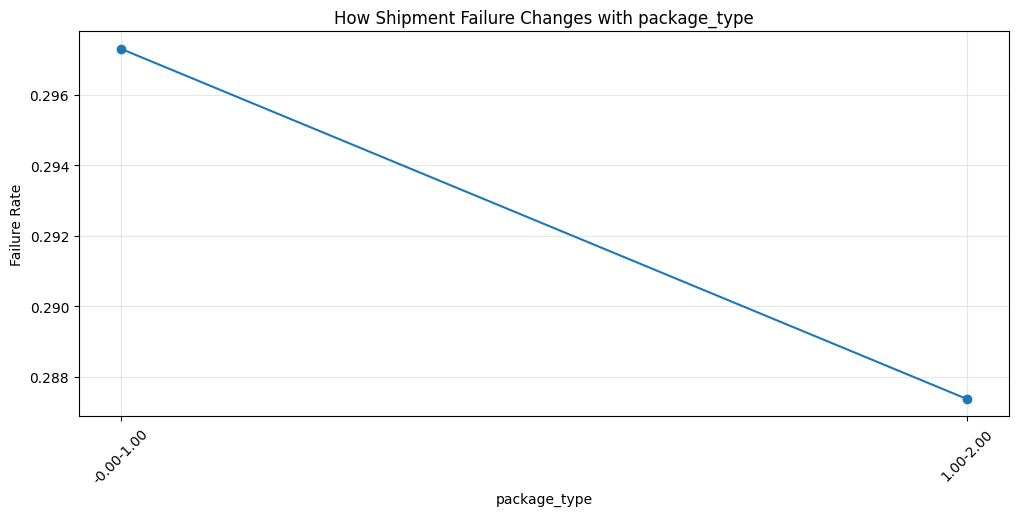

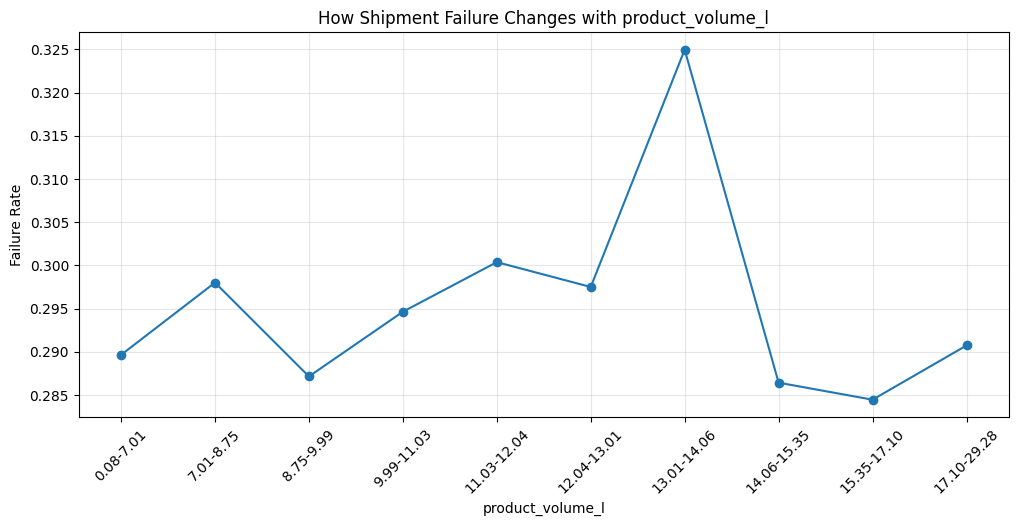

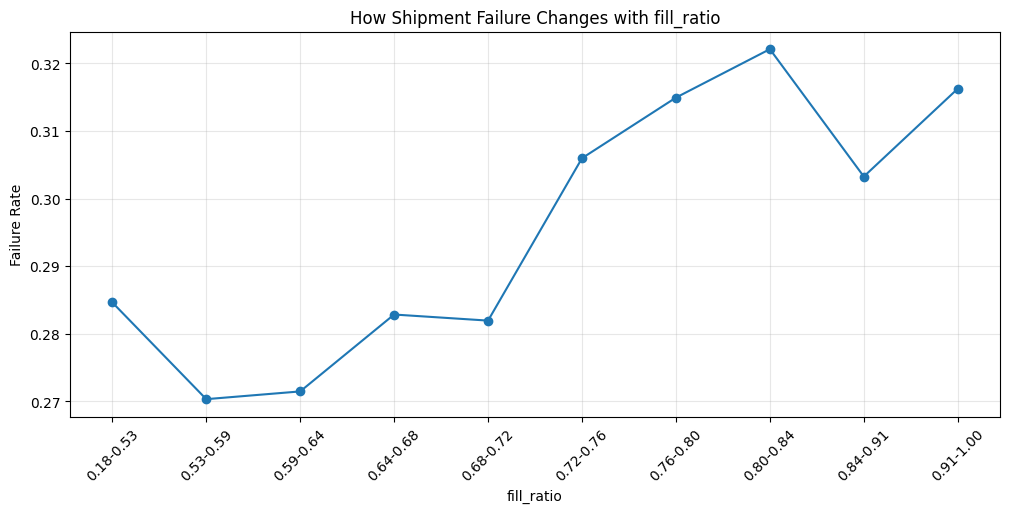

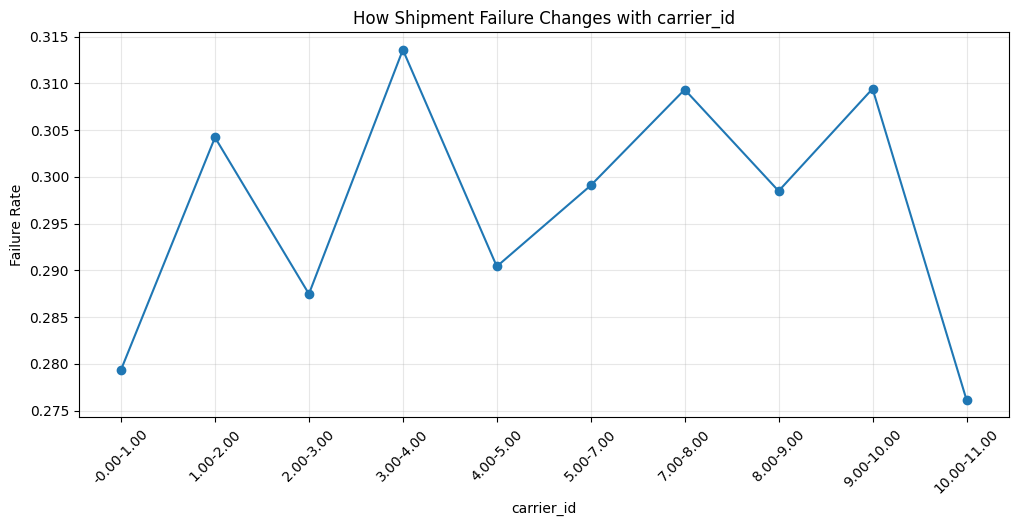

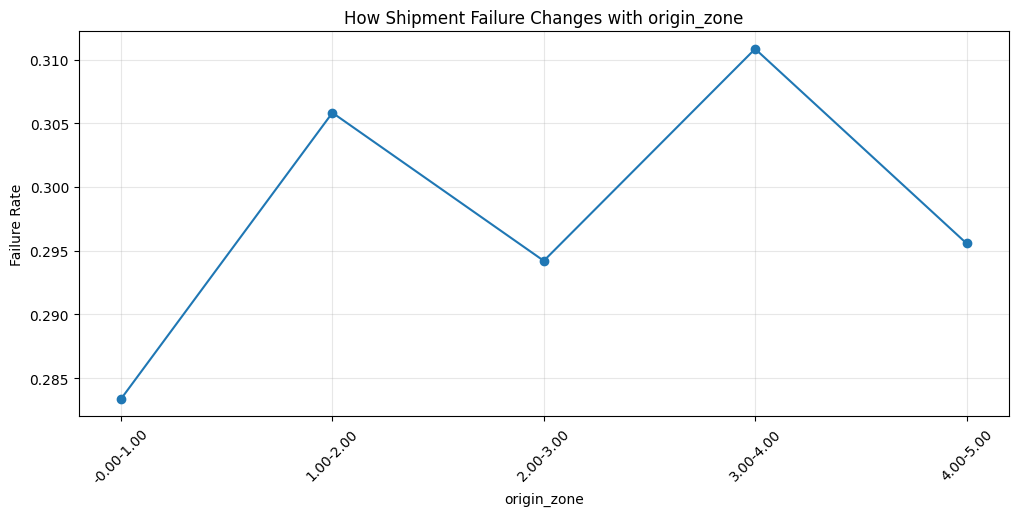

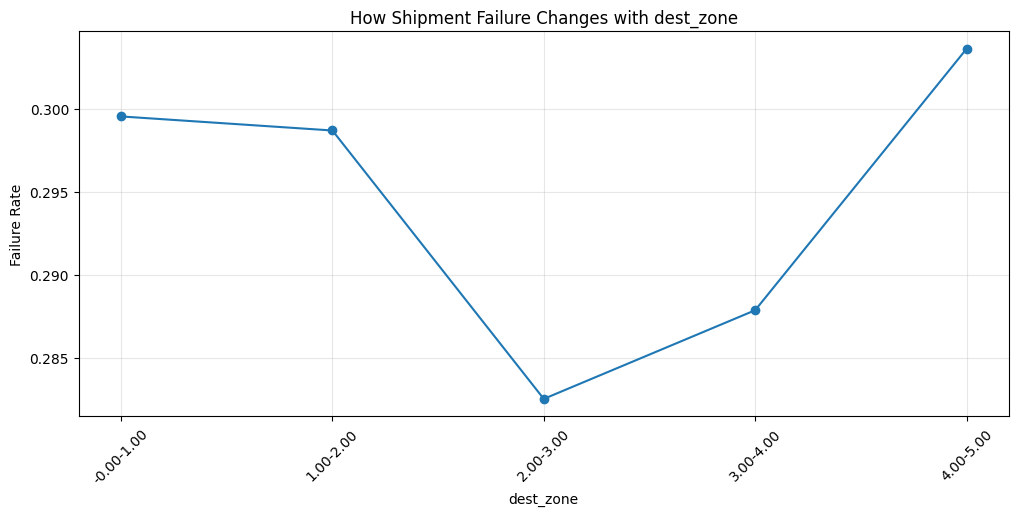

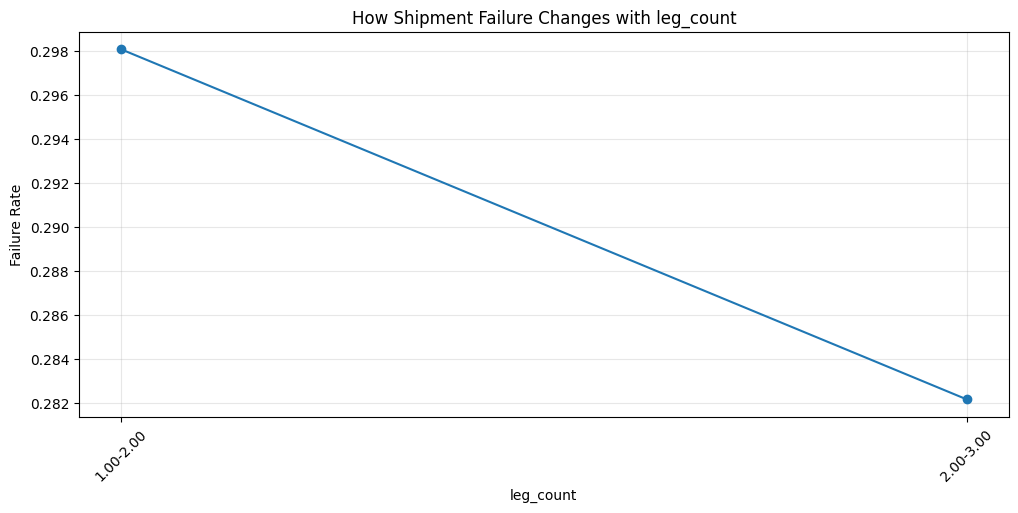

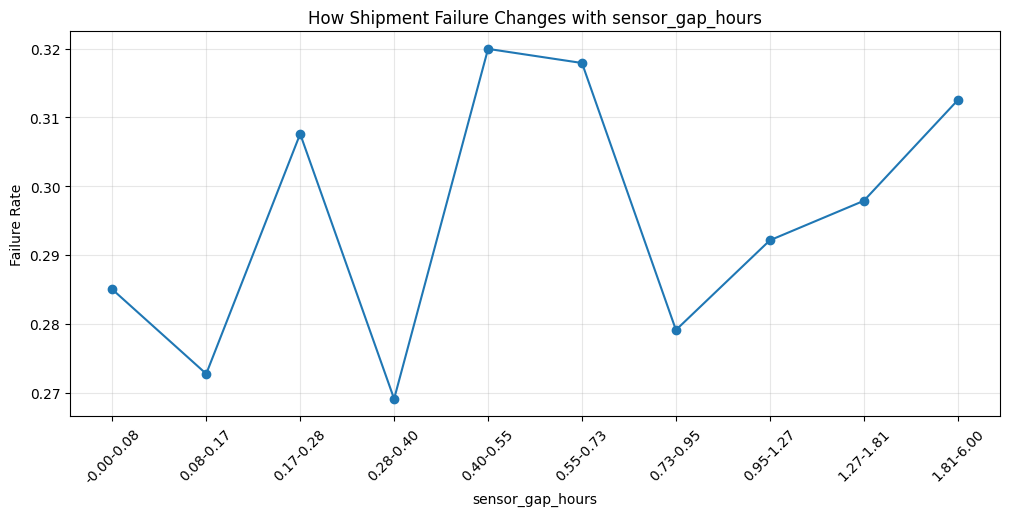

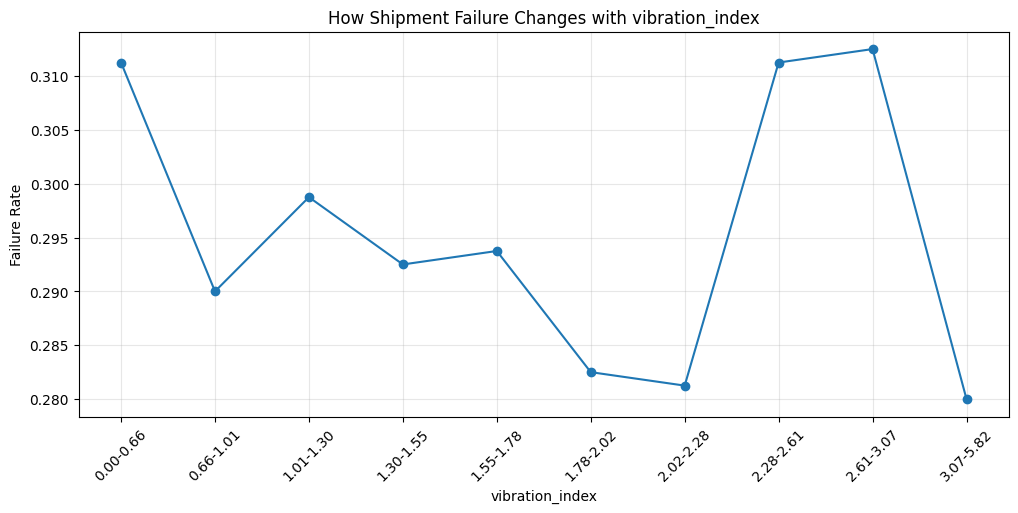

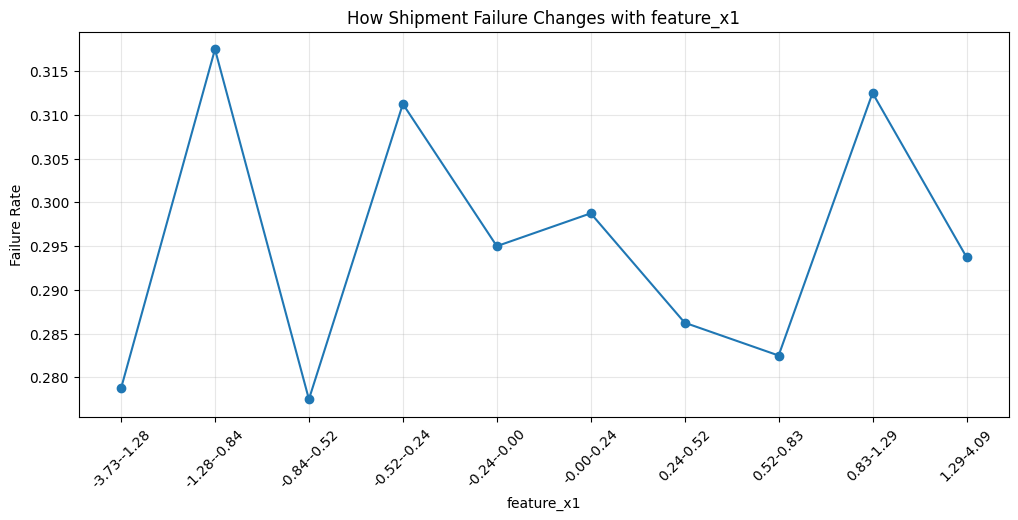

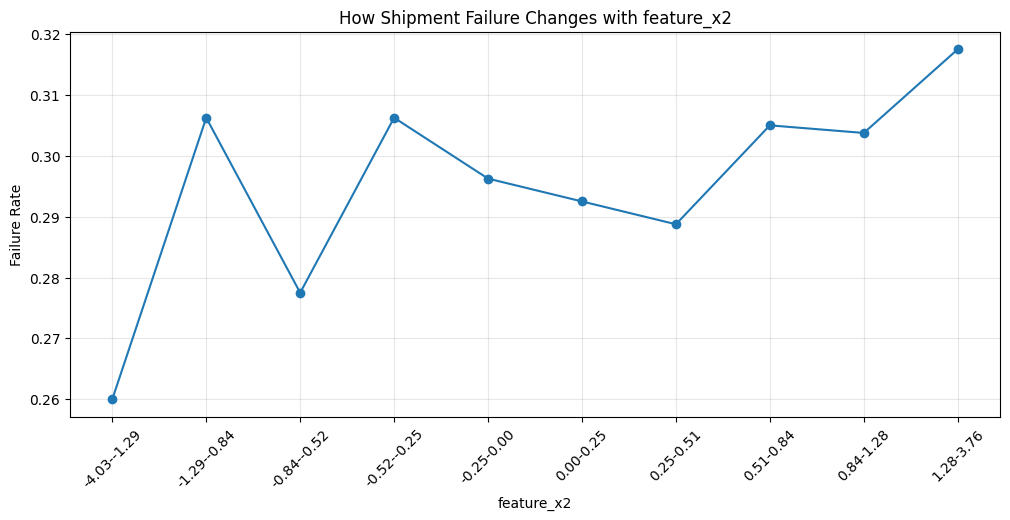

In [146]:


# Numerical features excluding target and identifiers
numerical_features = [
    col for col in df1.select_dtypes(include=np.number).columns
    if col not in ['shipment_failure']
]

for feature in numerical_features:
    
    try:
        # Create quantile bins
        temp_df = df1[[feature, 'shipment_failure']].copy()
        
        temp_df['bin'] = pd.qcut(
            temp_df[feature],
            q=10,
            duplicates='drop'
        )

        # Calculate failure rate
        failure_rate = (
            temp_df.groupby('bin', observed=False)['shipment_failure']
            .mean()
            .reset_index()
        )

        # Plot
        plt.figure(figsize=(12, 5))

        plt.plot(
            range(len(failure_rate)),
            failure_rate['shipment_failure'],
            marker='o'
        )

        plt.xticks(
            range(len(failure_rate)),
            [
                f"{interval.left:.2f}-{interval.right:.2f}"
                for interval in failure_rate['bin']
            ],
            rotation=45
        )

        plt.ylabel('Failure Rate')
        plt.xlabel(feature)
        plt.title(f'How Shipment Failure Changes with {feature}')
        plt.grid(alpha=0.3)

        plt.show()

    except Exception as e:
        print(f"Could not process {feature}: {e}")

In [147]:
df1.isnull().sum()

transit_days        0
door_opens          0
temp_mean_c         0
rh_mean             0
package_type        0
product_volume_l    0
fill_ratio          0
carrier_id          0
origin_zone         0
dest_zone           0
leg_count           0
sensor_gap_hours    0
vibration_index     0
feature_x1          0
feature_x2          0
shipment_failure    0
dtype: int64

In [148]:
df1['shipment_failure'].value_counts()

shipment_failure
0    5637
1    2363
Name: count, dtype: int64

In [160]:
#train test split
X_train,X_test,y_train,y_test = train_test_split(df1.drop(columns=['shipment_failure']),
                                                 df1['shipment_failure'],
                                                 test_size=0.3,
                                                random_state=42,
                                                stratify = df1['shipment_failure'])

In [161]:
print(len(X_train))
print(len(X_test))

5600
2400


In [162]:

X_train.head()

,transit_days,door_opens,temp_mean_c,rh_mean,package_type,product_volume_l,fill_ratio,carrier_id,origin_zone,dest_zone,leg_count,sensor_gap_hours,vibration_index,feature_x1,feature_x2
5985,1.515,2,3.756,0.4114,0,13.98,0.7569,7,2,5,2,0.371,1.6029,-0.7176,0.9782
585,3.807,12,3.583,0.6126,1,8.26,0.5943,3,3,3,1,1.275,2.2720,0.0710,2.0887
1579,12.220,11,2.029,0.6767,2,10.36,0.6632,10,0,0,3,1.262,1.5346,0.9683,-0.1868
6364,1.485,6,4.419,0.4408,0,20.89,0.9618,0,4,2,3,0.414,1.8486,1.5188,-0.5947
5171,4.339,10,6.311,0.7050,0,17.91,0.5413,7,0,5,2,0.165,0.9051,-0.2051,-0.9242


In [163]:
#sampling the minority samples
ros = RandomOverSampler()
x_train, Y_train = ros.fit_resample(X_train, y_train)

In [164]:
#using catboost classifier
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=200,
    depth=5,
    learning_rate=0.05,
    verbose=0
)
model.fit(x_train, Y_train)

CatBoostClassifier(depth=5, iterations=200, learning_rate=0.05, verbose=0)

In [168]:
#evaluating the model on test data
y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.50).astype(int)
acc = accuracy_score(y_test, y_pred)
print(acc)

0.5695833333333333


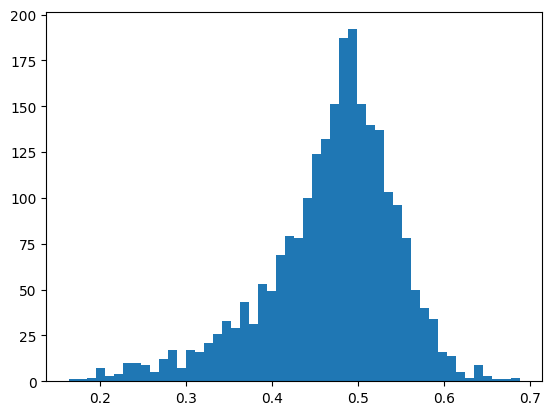

In [169]:
#observing the distribution 
plt.hist(y_prob, bins=50)
plt.show()

In [170]:
#evaluating using precision, recall and f1 score
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.72      0.65      0.68      1691
           1       0.31      0.39      0.35       709

    accuracy                           0.57      2400
   macro avg       0.52      0.52      0.51      2400
weighted avg       0.60      0.57      0.58      2400



In [171]:
#roc-auc score
roc_auc = roc_auc_score(y_test, y_prob)
print(roc_auc)

0.5136552177419826
